IN CLASS EXERCISE: Can the world be divided into developed and developing countries using data-driven clustering? If so, how well does a 2-cluster solution explain the data? How many clusters are recommended to explain 90%+ of variation?

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/manoelgadi/PSDMA/refs/heads/main/datasets/UN.csv")
df

,country,region,tfr,contraception,educationMale,educationFemale,lifeMale,lifeFemale,infantMortality,GDPperCapita,economicActivityMale,economicActivityFemale,illiteracyMale,illiteracyFemale
0,Afghanistan,Asia,6.90,NaN,NaN,NaN,45.0,46.0,154.0,2848.0,87.5,7.2,52.800,85.000
1,Albania,Europe,2.60,NaN,NaN,NaN,68.0,74.0,32.0,863.0,NaN,NaN,NaN,NaN
2,Algeria,Africa,3.81,52.0,11.1,9.9,67.5,70.3,44.0,1531.0,76.4,7.8,26.100,51.000
3,American.Samoa,Asia,NaN,NaN,NaN,NaN,68.0,73.0,11.0,NaN,58.8,42.4,0.264,0.360
4,Andorra,Europe,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202,Western.Sahara,Africa,3.98,NaN,NaN,NaN,59.8,63.1,64.0,NaN,NaN,NaN,NaN,NaN
203,Yemen,Asia,7.60,7.0,NaN,NaN,57.4,58.4,80.0,732.0,80.6,1.9,32.406,69.552
204,Yugoslavia,Europe,1.80,NaN,NaN,NaN,69.8,75.3,19.0,1487.0,NaN,NaN,1.782,9.072
205,Zambia,Africa,5.49,25.0,7.9,6.8,42.2,43.7,103.0,382.0,NaN,NaN,14.400,28.700


In [3]:
df.isna().sum() / len(df)

country                   0.000000
region                    0.000000
tfr                       0.048309
contraception             0.304348
educationMale             0.632850
educationFemale           0.632850
lifeMale                  0.053140
lifeFemale                0.053140
infantMortality           0.028986
GDPperCapita              0.048309
economicActivityMale      0.202899
economicActivityFemale    0.202899
illiteracyMale            0.227053
illiteracyFemale          0.227053
dtype: float64

In [4]:
df = df.drop(columns=['educationFemale','educationMale'])

In [5]:
pip install impyute

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
np.float = float
import impyute as impy

print(f"Number of missing values in the current DataFrame: {df.isnull().sum().sum()}")

if df.isnull().sum().sum() == 0:
    print("The DataFrame currently has no missing values, so EM imputation will not change it.")
    print("If you wish to impute, you might need to revert to a DataFrame state before `dropna()` was applied.")
else:
    # Separate numeric and non-numeric columns
    numeric_df = df.select_dtypes(include=np.number)
    non_numeric_df = df.select_dtypes(exclude=np.number)

    # Convert the numeric DataFrame to a NumPy array of float64 for impyute
    # impyute.imputation.cs.em expects a NumPy array with a float dtype
    data_for_imputation = numeric_df.astype(np.float64).values

    # Perform EM imputation
    imputed_data_array = impy.imputation.cs.em(data_for_imputation)

    # Convert the imputed array back to a DataFrame
    imputed_numeric_df = pd.DataFrame(imputed_data_array, columns=numeric_df.columns, index=numeric_df.index)

    # Recombine with non-numeric columns
    df_imputed = pd.concat([non_numeric_df, imputed_numeric_df], axis=1)

    # Verify that there are no more missing values
    print(f"Number of missing values after EM imputation: {df_imputed.isnull().sum().sum()}")
    print("Imputed DataFrame head:")
    display(df_imputed.head())

Number of missing values in the current DataFrame: 289
Number of missing values after EM imputation: 0
Imputed DataFrame head:


,country,region,tfr,contraception,lifeMale,lifeFemale,infantMortality,GDPperCapita,economicActivityMale,economicActivityFemale,illiteracyMale,illiteracyFemale
0,Afghanistan,Asia,6.900000,43.768188,45.000000,46.000000,154.000000,2848.000000,87.500000,7.200000,52.800000,85.000000
1,Albania,Europe,2.600000,-14.526457,68.000000,74.000000,32.000000,863.000000,75.249540,26.017476,4.198614,7.798530
2,Algeria,Africa,3.810000,52.000000,67.500000,70.300000,44.000000,1531.000000,76.400000,7.800000,26.100000,51.000000
3,American.Samoa,Asia,0.547868,17.602106,68.000000,73.000000,11.000000,-368.513699,58.800000,42.400000,0.264000,0.360000
4,Andorra,Europe,3.434704,39.849402,69.329298,66.240333,58.979431,12051.676554,69.292659,20.194312,17.127863,52.113126


In [7]:
df_imputed.shape

(207, 12)

First, variables with more than 40% missing values were removed from the dataset, as such a high proportion of missing data may compromise the reliability of the analysis. For the remaining variables, missing values were imputed when the proportion of missing observations was between 10% and 40%, following the common rule of thumb that variables within this range can be safely imputed without substantially biasing the results.

<Axes: >

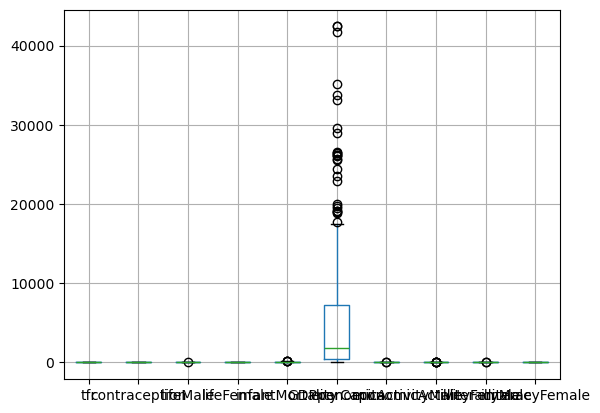

In [8]:
df.boxplot()

The data was then scaled to ensure that all variables contribute equally to the clustering process. Since clustering algorithms such as K-means rely on distance calculations, variables with larger numerical ranges could otherwise dominate the results. By standardizing the variables, we ensure that differences in scale do not bias the clustering and that each variable has a comparable influence on the distance calculations.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df_imputed.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df_imputed[col] = scaler.fit_transform(df_imputed[[col]])

df_imputed.head()

,country,region,tfr,contraception,lifeMale,lifeFemale,infantMortality,GDPperCapita,economicActivityMale,economicActivityFemale,illiteracyMale,illiteracyFemale
0,Afghanistan,Asia,1.951926,0.153427,-1.887439,-2.033793,2.890649,-0.378569,1.563841,-2.194934,1.983701,2.224302
1,Albania,Europe,-0.491180,-2.377231,0.486491,0.513824,-0.296012,-0.593011,-0.061405,-1.084798,-0.649473,-0.716845
2,Algeria,Africa,0.196298,0.510782,0.434884,0.177175,0.017430,-0.520846,0.091224,-2.159537,0.537122,0.929003
3,American.Samoa,Asia,-1.657128,-0.982482,0.486491,0.422838,-0.844535,-0.726054,-2.243736,-0.118313,-0.862646,-1.000231
4,Andorra,Europe,-0.016932,-0.016694,0.623694,-0.192200,0.408696,0.615720,-0.851694,-1.428335,0.051021,0.971410


PCA was applied to the scaled dataset to reduce dimensionality while preserving most of the variation in the data. A new dataframe containing the principal components was then created to simplify further analysis and visualization. The country names were appended to this dataframe to allow each observation to be identified and interpreted when examining the clustering results. Then using KMeans we cluster the data.

In [10]:
import seaborn as sns
from sklearn.decomposition import PCA

# Select only the numeric columns for PCA
numeric_df_for_pca = df_imputed.select_dtypes(include=['number'])

pca = PCA(n_components=10)
df_pca = pca.fit_transform(numeric_df_for_pca)

explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.51794019 0.11970092 0.0991569  0.08191367 0.06525007 0.05421157
 0.02849746 0.01907603 0.01053075 0.00372245]


In [11]:
df_pca

array([[-5.25982959,  0.22336268, -2.11085921, ..., -0.34719309,
         0.55039169,  0.35638033],
       [ 0.27996226, -1.72174176,  0.26372218, ..., -0.60650548,
         0.20084251,  0.0424275 ],
       [-0.46719186, -0.97484374, -2.07819014, ..., -0.2998191 ,
         0.06997756,  0.049677  ],
       ...,
       [ 1.11012223, -2.79792457, -0.45258423, ..., -0.69634791,
         0.07866805,  0.0403454 ],
       [-3.22341244, -1.84370544,  0.5773748 , ..., -0.09788037,
        -0.30719846, -0.05836299],
       [-1.75947992, -0.05426025,  1.19828806, ...,  0.15298783,
        -0.60162368, -0.28822828]], shape=(207, 10))

In [12]:
df_pca = pd.DataFrame(df_pca, columns = [f'PC{i+1}' for i in range(df_pca.shape[1])])
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-5.259830,0.223363,-2.110859,0.197826,-0.254337,1.799498,-0.336838,-0.347193,0.550392,0.356380
1,0.279962,-1.721742,0.263722,1.275782,1.381395,-1.349346,-0.264170,-0.606505,0.200843,0.042428
2,-0.467192,-0.974844,-2.078190,0.638315,-0.741640,0.259112,0.075265,-0.299819,0.069978,0.049677
3,1.783682,-2.220482,1.156532,-0.593382,-0.209571,-1.338057,-0.426419,-0.545536,0.031542,-0.209020
4,-0.175035,-1.105026,-1.377818,-0.629110,0.137837,0.371515,0.607739,-0.588781,0.396091,-0.329554
...,...,...,...,...,...,...,...,...,...,...
202,0.321625,-0.646029,1.148717,-0.602776,-0.727158,1.371611,0.481420,0.222508,0.156610,-0.093235
203,-3.530446,-1.319038,-1.893826,1.099684,0.705138,0.207439,0.789038,0.169538,-0.205919,0.015699
204,1.110122,-2.797925,-0.452584,0.692883,0.539162,-0.799289,-0.316653,-0.696348,0.078668,0.040345
205,-3.223412,-1.843705,0.577375,-0.152641,0.138760,1.574248,-0.628183,-0.097880,-0.307198,-0.058363


In [13]:
from sklearn.cluster import KMeans

kmeans2 = KMeans(n_clusters=5, random_state=42)
clusters2 = kmeans2.fit_predict(df_pca) # Use only PC columns for clustering


In [14]:
df_pca["cluster_2"] = clusters2
df_pca['country'] = df_imputed['country']

In [15]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_2,country
0,-5.259830,0.223363,-2.110859,0.197826,-0.254337,1.799498,-0.336838,-0.347193,0.550392,0.356380,3,Afghanistan
1,0.279962,-1.721742,0.263722,1.275782,1.381395,-1.349346,-0.264170,-0.606505,0.200843,0.042428,4,Albania
2,-0.467192,-0.974844,-2.078190,0.638315,-0.741640,0.259112,0.075265,-0.299819,0.069978,0.049677,1,Algeria
3,1.783682,-2.220482,1.156532,-0.593382,-0.209571,-1.338057,-0.426419,-0.545536,0.031542,-0.209020,4,American.Samoa
4,-0.175035,-1.105026,-1.377818,-0.629110,0.137837,0.371515,0.607739,-0.588781,0.396091,-0.329554,1,Andorra
...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.321625,-0.646029,1.148717,-0.602776,-0.727158,1.371611,0.481420,0.222508,0.156610,-0.093235,0,Western.Sahara
203,-3.530446,-1.319038,-1.893826,1.099684,0.705138,0.207439,0.789038,0.169538,-0.205919,0.015699,1,Yemen
204,1.110122,-2.797925,-0.452584,0.692883,0.539162,-0.799289,-0.316653,-0.696348,0.078668,0.040345,4,Yugoslavia
205,-3.223412,-1.843705,0.577375,-0.152641,0.138760,1.574248,-0.628183,-0.097880,-0.307198,-0.058363,3,Zambia


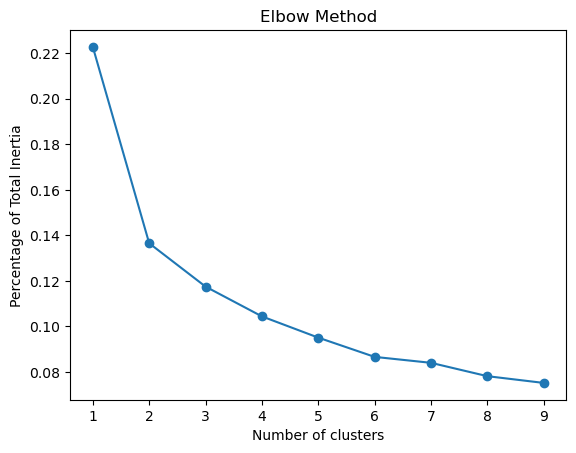

In [16]:
import matplotlib.pyplot as plt
import numpy as np

K = range(1,10)
inertia = [
    KMeans(n_clusters=k, random_state=42).fit(df_pca.iloc[:,:-2]).inertia_
    for k in K
]

# Convert to numpy array for element-wise operations and normalize to percentages
inertia_percentage = np.array(inertia) / np.sum(inertia)

plt.plot(K, inertia_percentage, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Percentage of Total Inertia")
plt.title("Elbow Method")
plt.show()


In [17]:
sum(inertia_percentage[0:5])

np.float64(0.6761694547764154)

Based on the elbow curve, five clusters appear to be the optimal number. After this point, the reduction in inertia becomes much smaller and the curve begins to flatten, suggesting that additional clusters contribute little additional explanatory power.

In [18]:
df_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_2,country
0,-5.259830,0.223363,-2.110859,0.197826,-0.254337,1.799498,-0.336838,-0.347193,0.550392,0.356380,3,Afghanistan
1,0.279962,-1.721742,0.263722,1.275782,1.381395,-1.349346,-0.264170,-0.606505,0.200843,0.042428,4,Albania
2,-0.467192,-0.974844,-2.078190,0.638315,-0.741640,0.259112,0.075265,-0.299819,0.069978,0.049677,1,Algeria
3,1.783682,-2.220482,1.156532,-0.593382,-0.209571,-1.338057,-0.426419,-0.545536,0.031542,-0.209020,4,American.Samoa
4,-0.175035,-1.105026,-1.377818,-0.629110,0.137837,0.371515,0.607739,-0.588781,0.396091,-0.329554,1,Andorra
...,...,...,...,...,...,...,...,...,...,...,...,...
202,0.321625,-0.646029,1.148717,-0.602776,-0.727158,1.371611,0.481420,0.222508,0.156610,-0.093235,0,Western.Sahara
203,-3.530446,-1.319038,-1.893826,1.099684,0.705138,0.207439,0.789038,0.169538,-0.205919,0.015699,1,Yemen
204,1.110122,-2.797925,-0.452584,0.692883,0.539162,-0.799289,-0.316653,-0.696348,0.078668,0.040345,4,Yugoslavia
205,-3.223412,-1.843705,0.577375,-0.152641,0.138760,1.574248,-0.628183,-0.097880,-0.307198,-0.058363,3,Zambia


In [19]:
df_pca[df_pca['country'] == 'Spain']

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_2,country
172,2.973822,-1.133611,-0.281103,-0.818726,-0.211293,0.053522,0.127122,-0.057538,0.235901,0.10001,4,Spain


We can see that Spain is in Cluster 0 with Portugal, Argentina, etc.

In [20]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


We now plot the PCA Graph by highligthing the name of the country and by visually dividng the clusters with colors

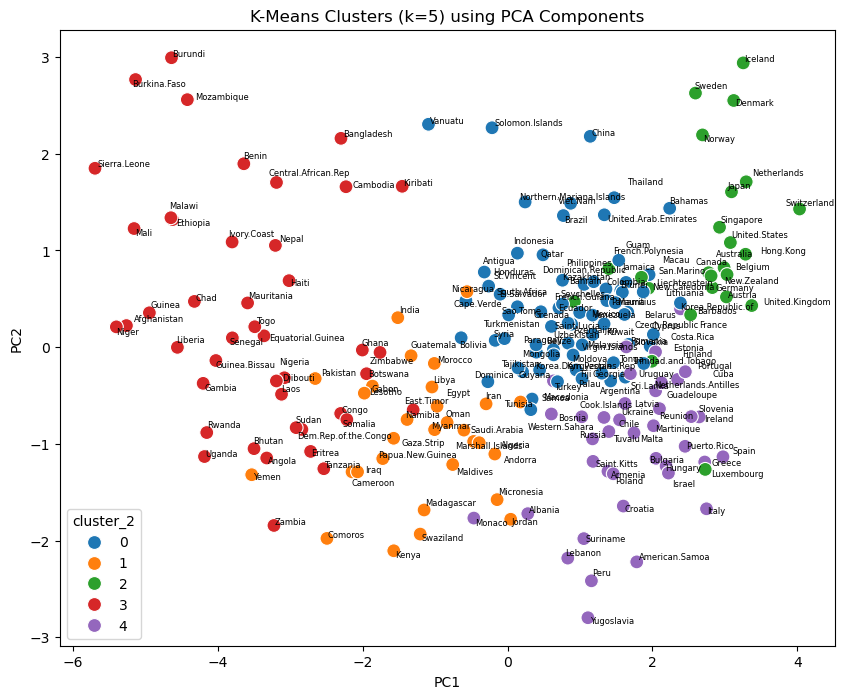

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_2",
    palette="tab10",
    s=100
)

texts = []

for i in range(len(df_pca)):
    texts.append(
        plt.text(
            df_pca["PC1"][i],
            df_pca["PC2"][i],
            df_pca["country"][i],
            fontsize=6
        )
    )

adjust_text(texts)

plt.title("K-Means Clusters (k=5) using PCA Components")
plt.show()

This analysis explored whether countries can be divided into developed and developing groups using data-driven clustering methods. After preparing the data through cleaning, outlier inspection, and scaling, PCA was applied to understand the structure and variation within the dataset. The results show that while a two-cluster solution roughly separates countries into groups resembling developed and developing economies, it does not fully capture the variation present in the data. Visualization using the first two principal components indicates that several countries fall between these two groups. Using the elbow method, a five-cluster solution appears to better represent the underlying structure of the dataset. This suggests that global development is more complex than a simple binary classification. Instead, countries form multiple clusters that reflect different levels and patterns of development. Therefore, while a two-cluster solution provides a rough distinction, a larger number of clusters offers a more nuanced and informative segmentation of countries.